# Dataset Description

The dataset for this competition (both train and test) was generated from a deep learning model trained on the Diabetes Health Indicators Dataset. Feature distributions are close to, but not exactly the same, as the original. Feel free to use the original dataset as part of this competition, both to explore differences as well as to see whether incorporating the original in training improves model performance. diagnosed_diabetes is the target, and for the testing data, you should predict the probability of diagnosed_diabetes

Submissions are evaluated on area under the ROC curve between the predicted probability and the observed target.

# Scoring 0.62113
# Place 3611 / 4038 ( Top 89.5% )

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler


In [2]:
sns.set_style('whitegrid')

In [4]:
dtype={
                        'age': np.float16,
                        'alcohol_consumption_per_week': 'uint8',
                        'physical_activity_minutes_per_week': 'uint8',
                        'diet_score': np.float16,
                        'sleep_hours_per_day': np.float16,
                        'screen_time_hours_per_day': np.float16,
                        'bmi': np.float16,
                        'waist_to_hip_ratio': np.float16,
                        'systolic_bp': np.uint8,
                        'diastolic_bp': np.uint8,
                        'heart_rate': np.uint8,
                        'cholesterol_total': np.uint8,
                        'hdl_cholesterol': np.uint8,
                        'ldl_cholesterol': np.uint8,
                        'triglycerides': np.uint8,
                        'family_history_diabetes': np.bool_,
                        'hypertension_history': np.bool_,
                        'cardiovascular_history': np.bool_,
                    }

train = pd.read_csv('./data/diabetes/train.zip', index_col='id', dtype=dtype)
test = pd.read_csv('./data/diabetes/test.zip', index_col='id', dtype=dtype)

In [23]:
train.dtypes

age                                   float16
alcohol_consumption_per_week            uint8
physical_activity_minutes_per_week      uint8
diet_score                            float16
sleep_hours_per_day                   float16
screen_time_hours_per_day             float16
bmi                                   float16
waist_to_hip_ratio                    float16
systolic_bp                             uint8
diastolic_bp                            uint8
heart_rate                              uint8
cholesterol_total                       uint8
hdl_cholesterol                         uint8
ldl_cholesterol                         uint8
triglycerides                           uint8
gender                                    str
ethnicity                                 str
education_level                           str
income_level                              str
smoking_status                            str
employment_status                         str
family_history_diabetes           

In [24]:
train.memory_usage().sum() / 1024**2  # Memory usage in MB (138.85 MB) vs 53.40 MB after optimization ~ 2.6 times reduction

np.float64(53.405887603759766)

In [5]:
numerical_columns = train.select_dtypes(include=[np.number]).columns.tolist()
numerical_columns.remove('diagnosed_diabetes')
one_hot_columns = ['ethnicity', 'smoking_status', 'employment_status']
categorical_columns = ['education_level', 'income_level']

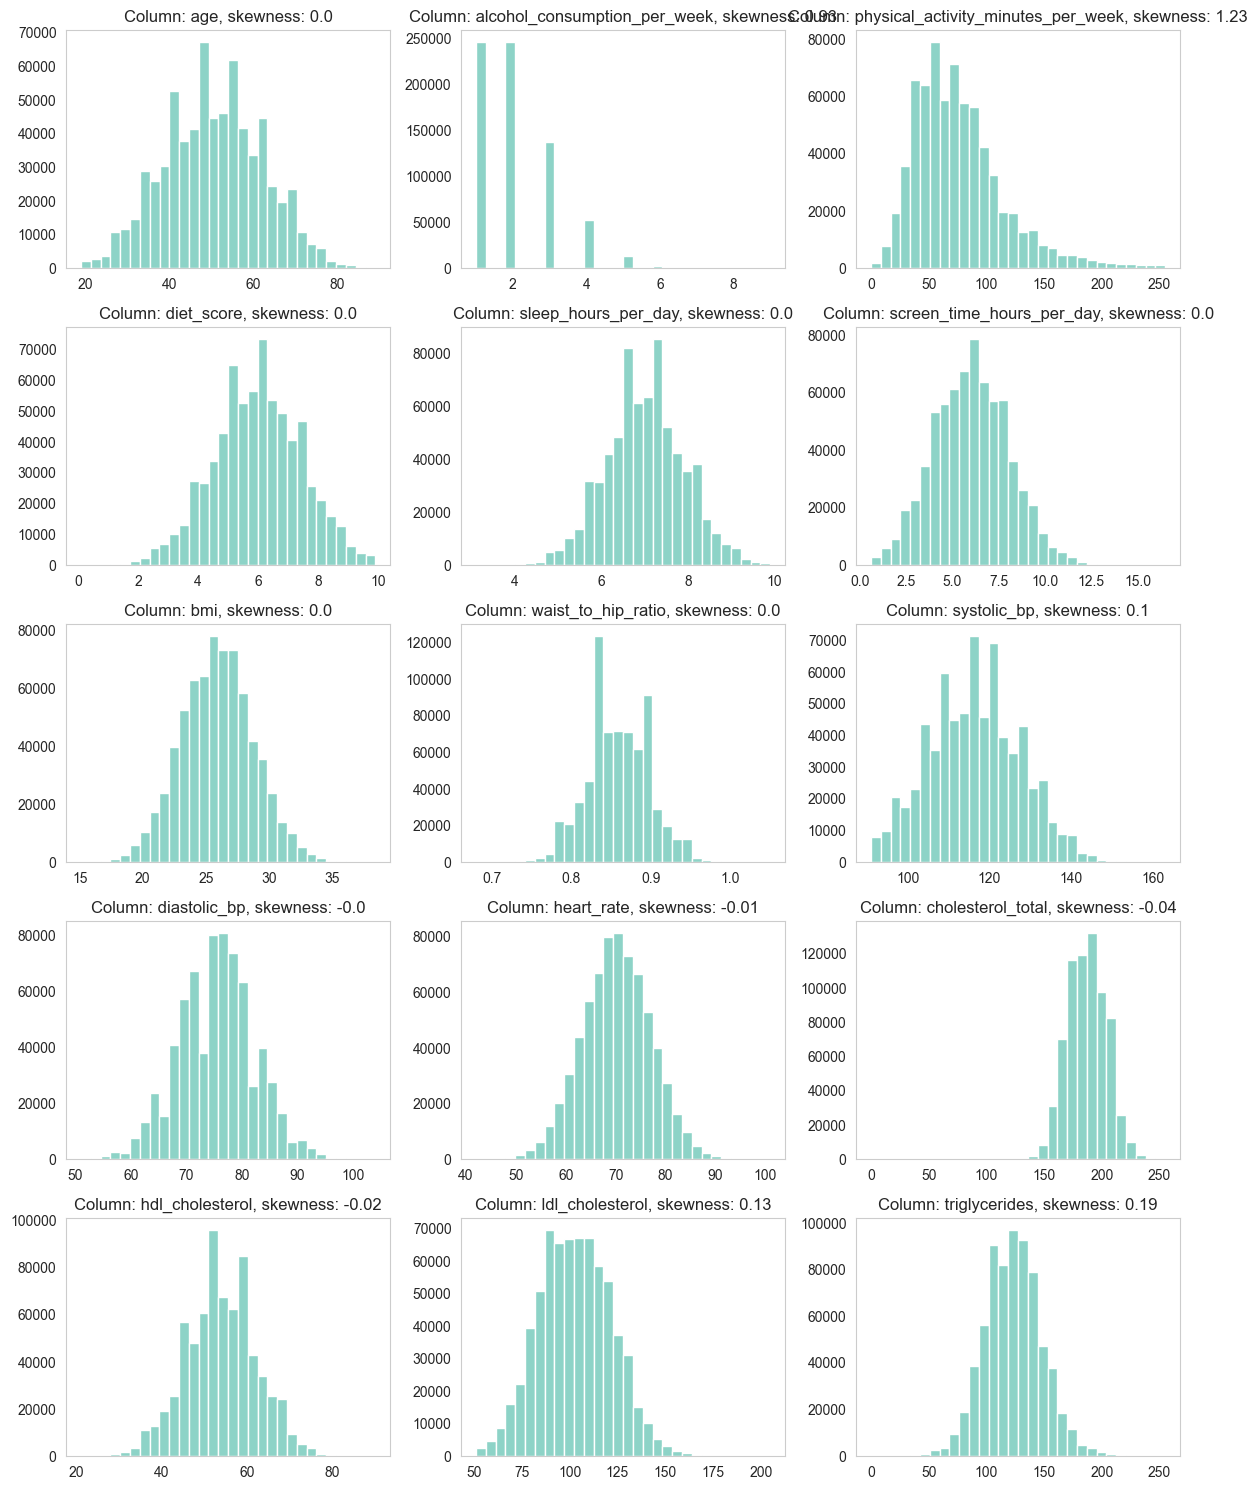

In [16]:
import math

ncols = 3
n = len(numerical_columns)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 3*nrows))
axes = axes.ravel()  # flatten to 1D indexing

for idx, col in enumerate(numerical_columns):
    ax = axes[idx]
    ax.hist(train[col].dropna(), bins=30)
    ax.set_title(f'Column: {col}, skewness: {np.round(train[col].skew(), 2)}')
    ax.grid(False)

# turn off any unused axes (when n is not a multiple of ncols)
for j in range(n, nrows * ncols):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [26]:
X, y = train.drop('diagnosed_diabetes', axis=1), train['diagnosed_diabetes']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [27]:
# let's prepare pipeline for preprocessing
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

one_hot_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

categorical_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_columns),
        ('onehot', one_hot_transformer, one_hot_columns),
        ('cat', categorical_transformer, categorical_columns),
    ])

In [28]:
classifier = GaussianNB(  # best AOC score 0.6319646895734179
    var_smoothing=4.690800298238548e-08
)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', classifier)
])

In [29]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [37]:
y_pred = model.predict_proba(test)[:, 1]

In [38]:
# let's prepare submission file
submission = pd.DataFrame(
    {
        'id': test.index,
        'diagnosed_diabetes': y_pred
    }
)

In [39]:
submission.head(10)

,id,diagnosed_diabetes
0,700000,0.707143
1,700001,0.580020
2,700002,0.829510
3,700003,0.779790
4,700004,0.797897
5,700005,0.462361
6,700006,0.934192
7,700007,0.835476
8,700008,0.659873
9,700009,0.861543


In [ ]:
submission.to_csv('/kaggle/working/submission.csv', index=False)